In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')

In [2]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


In [ ]:
import os
import glob
import gc
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.loader import DataLoader
import ipaddress


In [ ]:
from utils.datasets import NF_IDS_Dataset
from utils.models   import ST_GNN_Identity
from utils.metrics  import calculate_full_temporal_metrics, evaluation_soc
from utils.mitre     import (get_mitre_tactic, canonical_tactic,
                             extract_mitre_events, count_total_flows,
                             metrics_per_tactic, analyze_timeline,
                             analyze_early_warning,
                             analyze_all_lateral_movements_pairs)


# Functions

## Count attack IP pairs

In [ ]:
@torch.no_grad()
def count_attack_ip_pairs(loader, device, id_to_ip_dict):
    """
    Count the IP pairs of the Ground Truth (y==1)
    """
    count_pairs = Counter()

    for batch_idx, data in enumerate(loader):
        data = data.to(device)
        if data.x.shape[0] == 0: continue

        trues = data.y.cpu().numpy()
        edges = data.edge_index.cpu().numpy()
        global_ids = data.global_node_ids.cpu().numpy()

        # Filter only the indexes where there is an attack
        attack_indexes = np.where(trues == 1)[0]

        for i in attack_indexes:
            local_src = edges[0, i]
            local_dst = edges[1, i]

            src_ip = id_to_ip_dict.get(global_ids[local_src], "Unknown")
            dst_ip = id_to_ip_dict.get(global_ids[local_dst], "Unknown")

            count_pairs[(src_ip, dst_ip)] += 1

    return count_pairs

# Auxiliary

## Load model

In [7]:
# ── Model hyperparameters — must match your champion ───────────────────────
NODE_DIM   = 16
EDGE_DIM   = 32    # 7 (port) + 5 (protocol) + 20 (numeric)
HIDDEN_DIM = 32
DROPOUT    = 0.2
BIAS_VALUE = -2.9968

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device   : {DEVICE}")

# ── Classification threshold (from Day1 validation) ────────────────────────
opt_thresholds = np.load("/content/drive/MyDrive/nids-mitre/results_earlystopping/logs/ST_GNN_BiasOn_robust_Identity_clone/thresholds_ST_GNN_BiasOn_robust_Identity_clone.npz")
THRESHOLD  = opt_thresholds["seed_42"]

Device   : cpu


In [8]:
MODEL_PATH = "/content/drive/MyDrive/nids-mitre/results_earlystopping/saved_models/ST_GNN_BiasOn_robust_Identity_clone/ST_GNN_BiasOn_robust_Identity_clone_seed42_20260220_213225_AUC-PR_0.7718.pth"


model_stgnn = ST_GNN_Identity(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    output_bias_init = BIAS_VALUE
).to(DEVICE)

model_stgnn.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


<All keys matched successfully>

## Load data day 1 and day 2

In [9]:
ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed"

train_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='train')
val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')
test1_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test')

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test1 size: {len(test1_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False) # pin_memory=False for CPU
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
test1_loader = DataLoader(test1_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed/ip_map_day1.pkl", "rb") as f:
    ip_to_id_day1 = pickle.load(f)
id_to_ip_day1 = {v: k for k, v in ip_to_id_day1.items()}

Train size: 1998 | Val size: 428 | Test1 size: 429


In [10]:
test2_dataset = NF_IDS_Dataset(root_dir="/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103", split='test2')

print(f"Test2 size: {len(test2_dataset)}")

test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103/ip_map_day2.pkl", "rb") as f:
    ip_to_id_day2 = pickle.load(f)
id_to_ip_day2 = {v: k for k, v in ip_to_id_day2.items()}

Test2 size: 2822


# Main

## Day 1

### IP Pairs Analysis

In [ ]:
print("Processing Train...")
total_count = count_attack_ip_pairs(train_loader, DEVICE, id_to_ip_day1)
gc.collect()

print("Processing Val...")
total_count += count_attack_ip_pairs(val_loader, DEVICE, id_to_ip_day1)
gc.collect()

print("Processing Test1...")
total_count += count_attack_ip_pairs(test1_loader, DEVICE, id_to_ip_day1)
gc.collect()


results_day1 = [
    {'Source_IP': src, 'Dest_IP': dst, 'Count': count}
    for (src, dst), count in total_count.items()
]

df_top_ippairs_day1 = pd.DataFrame(results_day1).sort_values('Count', ascending=False)

print("\n TOP IP PAIRS (DAY 1):")
print(df_top_ippairs_day1.head(20))

Processing Train...
Processing Val...
Processing Test1...

 TOP IP PAIRS (DAY 1):
          Source_IP        Dest_IP  Count
94   172.229.222.45  94.182.163.51  10221
5     66.198.178.50   66.111.57.61   8680
8      52.50.201.26   66.111.57.61   8280
3     172.31.67.111   66.111.57.61   8060
1     65.52.108.213   66.111.57.61   7280
0      52.6.193.105   66.111.57.61   6364
2      23.239.24.18   66.111.57.61   4143
7     66.235.146.78   66.111.57.61   3698
4      131.202.1.45   66.111.57.61   3258
6     52.85.131.173   66.111.57.61   3040
291  172.229.222.45  65.52.108.213    891
270  172.229.222.45  172.31.67.111    755
249  172.229.222.45   52.6.193.105    720
358  172.229.222.45   52.50.201.26    703
95    37.230.149.51  66.198.178.50    696
111   37.230.149.51  65.52.108.213    650
373  172.229.222.45  66.198.178.50    568
152  172.229.222.45  52.85.131.173    488
131  172.229.222.45   131.202.1.45    483
102  172.229.222.45   23.239.24.18    481


In [ ]:
print(df_top_ippairs_day1[df_top_ippairs_day1["Dest_IP"] == "94.182.163.51"]["Source_IP"].nunique())

print(df_top_ippairs_day1[
    df_top_ippairs_day1["Dest_IP"] == "94.182.163.51"
]["Count"].sum())

130
10407


### Test 1

In [ ]:
 # Servers that receive massive exfiltration/control connections
C2_SERVERS_DAY1 = [
    "66.111.57.61",
    "94.182.163.51"
]

# Most of the external public IPs that are generating malicious traffic
EXTERNAL_ATTACKERS_DAY1 = [
    "172.229.222.45",
    "66.198.178.50",
    "52.50.201.26",
    "65.52.108.213",
    "52.6.193.105",
    "23.239.24.18",
    "66.235.146.78",
    "131.202.1.45",
    "52.85.131.173",
    "37.230.149.51"
]

In [ ]:
df_flows_test1 = extract_mitre_events(
    loader=test1_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day1,
    c2_servers=C2_SERVERS_DAY1,
    external_attackers=EXTERNAL_ATTACKERS_DAY1,
    internal_net="172.31.0.0/16"
)

df_flows_test1.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper/mitre_test1.csv", index=False)



df_gt_day1 = df_flows_test1[df_flows_test1['y_real'] == 1].copy()
df_all_pred_day1 = df_flows_test1[df_flows_test1['y_pred'] == 1].copy()
df_tp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 1) & (df_flows_test1['y_pred'] == 1)].copy()
df_fp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 0) & (df_flows_test1['y_pred'] == 1)].copy()

In [ ]:
total_flows_test1 = count_total_flows(test1_loader)
metrics_tactic_day1 = metrics_per_tactic(df_flows_test1, total_flows_test1, False)
print(metrics_tactic_day1.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
                              Command & Control                   296                       339                  290                    49          85.55       97.97         91.34         95.21 0.025603
External Malicious Infrastructure Communication                  3086                      2740                 2279                   461          83.18       73.85         78.24         75.54 0.244442
                                        Unknown                    24                       784                   14                   770           1.79       58.33          3.47          7.95 0.401764
                                 Initial Access                    28                         0                    0                     0           0.00        0.00          0.00         

## Day 2

### IP Pairs Analysis

In [ ]:
total_count2 = count_attack_ip_pairs(test2_loader, DEVICE, id_to_ip_day2)
gc.collect()

results_day2 = [
    {'Source_IP': src, 'Dest_IP': dst, 'Count': count}
    for (src, dst), count in total_count2.items()
]
df_top_ippairs_day2 = pd.DataFrame(results_day2).sort_values('Count', ascending=False)
print(df_top_ippairs_day2.head(20))



           Source_IP          Dest_IP  Count
405     54.85.40.222   117.198.97.175   9194
8      65.52.108.196     69.16.232.48   7470
0       172.31.67.15     69.16.232.48   7276
553     54.85.40.222     172.31.69.19   7157
587     54.85.40.222   177.45.135.226   7154
532     54.85.40.222     79.18.65.124   7149
2       152.163.50.3     69.16.232.48   6990
5     52.229.173.178     69.16.232.48   6448
4       172.31.68.30     69.16.232.48   6154
1     183.83.254.235     69.16.232.48   5934
3       172.31.67.52     69.16.232.48   5882
7       52.20.73.160     69.16.232.48   3162
22   183.220.102.254     172.31.67.52   1274
6       54.85.40.222     69.16.232.48   1251
24   183.220.102.254     152.163.50.3   1236
31   183.220.102.254     172.31.67.15   1206
588     54.85.40.222  222.142.206.100   1022
209  183.220.102.254   183.83.254.235    924
527     54.85.40.222     172.31.67.15    474
470     54.85.40.222   183.83.254.235    461


In [ ]:
candidates = ["117.198.97.175", "177.45.135.226", "79.18.65.124", "222.142.206.100"]

for ip in candidates:
    out_deg = df_top_ippairs_day2[df_top_ippairs_day2["Source_IP"] == ip]["Dest_IP"].nunique()
    in_deg = df_top_ippairs_day2[df_top_ippairs_day2["Dest_IP"] == ip]["Source_IP"].nunique()
    total_in = df_top_ippairs_day2[df_top_ippairs_day2["Dest_IP"] == ip]["Count"].sum()
    total_out = df_top_ippairs_day2[df_top_ippairs_day2["Source_IP"] == ip]["Count"].sum()
    print(ip, out_deg, in_deg, total_in, total_out)

117.198.97.175 3 121 9634 50
177.45.135.226 0 1 7154 0
79.18.65.124 3 112 7553 50
222.142.206.100 0 1 1022 0


### Test 2

In [18]:
C2_SERVERS_DAY2 = [
    "69.16.232.48",
    "117.198.97.175",
    "79.18.65.124"
]

EXTERNAL_ATTACKERS_DAY2 = [
    "54.85.40.222",
    "183.220.102.254",
    "65.52.108.196",
    "152.163.50.3",
    "52.229.173.178",
    "183.83.254.235",
    "52.20.73.160"
]



In [27]:
df_mitre_test2 = extract_mitre_events(
    loader=test2_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day2,
    c2_servers=C2_SERVERS_DAY2,
    external_attackers=EXTERNAL_ATTACKERS_DAY2,
    internal_net="172.31.0.0/16"
)

df_mitre_test2.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper/mitre_test2.csv", index=False)



df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [28]:
total_flows_test2 = count_total_flows(test2_loader)
metrics_tactic_day2 = metrics_per_tactic(df_mitre_test2, total_flows_test2, False)
print(metrics_tactic_day2.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
                                 Initial Access                 11042                     11137                10815                   322          97.11       97.94         97.52         97.78 0.015154
External Malicious Infrastructure Communication                 65547                     76099                62627                 13472          82.30       95.55         88.43         92.56 0.650692
                              Command & Control                 19320                     22244                18304                  3940          82.29       94.74         88.08         91.96 0.186144
                    Internal Malicious Activity                    94                       180                   72                   108          40.00       76.60         52.55         

### FP Analysis

In [29]:
# 1. Which ports are the most misleading to the model?
print("\n TOP PORTS THAT CAUSE FALSE ALARMS:")
print(df_fp_day2['Port_Category'].value_counts())

# 2. Which innocent machines (IPs) are most often identified as attackers?
print("\n TOP INNOCENT MACHINES ACCUSED (Source_IP):")
print(df_fp_day2['Source_IP'].value_counts().head(10))

# 3. Which innocent machine receives the most falsely malicious connections?
print("\n TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):")
print(df_fp_day2['Dest_IP'].value_counts().head(10))


 TOP PORTS THAT CAUSE FALSE ALARMS:
Port_Category
Windows/SMB                         28618
DNS                                 12073
Web                                 11410
Admin/Remote                         3325
High Ports / Ephemeral (>= 1024)     1107
Other Privileged (< 1024)               8
Database                                5
Name: count, dtype: int64

 TOP INNOCENT MACHINES ACCUSED (Source_IP):
Source_IP
172.31.64.4       28356
152.163.50.3       3400
172.31.67.15       3390
183.83.254.235     3180
52.229.173.178     3106
65.52.108.196      2762
172.31.67.52       2572
172.31.68.30       1962
52.20.73.160       1226
112.8.105.109       830
Name: count, dtype: int64

 TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):
Dest_IP
69.16.232.48      11941
172.31.65.88       1585
54.230.19.242      1584
66.17.123.196      1584
54.85.75.70        1581
216.58.218.234     1578
65.127.65.170      1578
172.31.65.66       1576
190.216.204.14     1575
172.31.64.65       1573
Name: co

In [30]:
flows_to_c2 = df_fp_day2[df_fp_day2['Dest_IP'] == '69.16.232.48']

print(" PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':")
print(flows_to_c2['Port_Category'].value_counts())

 PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':
Port_Category
DNS    11941
Name: count, dtype: int64


**Note:** It is very likely that the 11941 flows to `69.16.232.48` were *Unlabeled True Positive*.

In [33]:
soc_day2 = evaluation_soc(
    loader=test2_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    id_to_ip_dict=id_to_ip_day2,
    is_temporal=True,
    focus_ips=['172.31.64.4'],
    dns_suspicious_ips=['69.16.232.48'],
    smb_whitelist_ips=['172.31.64.4'],
    return_flow_df=True,
    verbose=True
)

# df_metrics_test2 = soc_day2["summary_df"]
# df_counts_test2 = soc_day2["counts_df"]
# df_focus_ips_test2 = soc_day2["focus_ip_df"]

df_preds_test2 = soc_day2["flow_df"]
df_preds_test2.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper/preds_test2.csv", index=False)



=== METRICS SUMMARY ===
                        Phase  Precision   Recall       F1       F2      FPR
          PHASE 1: RAW MATRIX   0.633625 0.941902 0.757604 0.858377 0.027826
PHASE 2: LABEL CORRECTION DNS   0.710993 0.947895 0.812528 0.888674 0.022080
 PHASE 3: SOC + WHITELIST SMB   0.871022 0.947895 0.907834 0.931454 0.008043

=== COUNTS ===
                        Phase     TP    FP      TN   FN
          PHASE 1: RAW MATRIX  97793 56546 1975586 6032
PHASE 2: LABEL CORRECTION DNS 109734 44605 1975586 6032
 PHASE 3: SOC + WHITELIST SMB 109734 16249 2003942 6032

 DNS correction applied: 11941 flows FP -> TP

=== IPs FOCUS VERIFICATION ===
         IP  Real_Attack_Flows  Whitelist_Safe
172.31.64.4                  0            True

 Whitelist SMB applied: 28356 flows FP -> TN


In [34]:
df_preds_raw = soc_day2['flow_df'].copy()

# ==========================================
# IMPLEMENTING THE SOC RULES (PHASE 3)
# ==========================================

# DNS Correction (FP -> TP): The reality was 0, but we discovered it is 1
df_preds_raw.loc[df_preds_raw['dns_rule_applied'] == 1, 'y_real'] = 1

# Whitelist SMB (FP -> TN): The model alerted (1), but the SOC silences it (0)
df_preds_raw.loc[df_preds_raw['smb_rule_applied'] == 1, 'y_pred'] = 0



# ==========================================
# OPTIMIZE MEMORY AND LABEL TACTICS
# ==========================================

# We discard millions of pure True Negatives to avoid overloading the RAM
# We only keep what is a real attack OR a model alert
df_flows_phase3 = df_preds_raw[(df_preds_raw['y_real'] == 1) | (df_preds_raw['y_pred'] == 1)].copy()

# Apply the function to obtain the tactic (only on the relevant flows)
df_flows_phase3['MITRE_Tactic'] = df_flows_phase3.apply(
    lambda row: get_mitre_tactic(
        row['Source_IP'],
        row['Dest_IP'],
        C2_SERVERS_DAY2,
        EXTERNAL_ATTACKERS_DAY2,
        row['Port_Category'],
        internal_net="172.31.0.0/16"
    ), axis=1
)

df_flows_phase3['MITRE_Tactic_Base'] = df_flows_phase3['MITRE_Tactic'].apply(canonical_tactic)


In [35]:
metrics_tactic_day2_phase3 = metrics_per_tactic(df_flows_phase3, total_flows_test2, False)
print("\n METRICS AFTER PHASE 2 and 3 WERE APPLIED (DAY 2):")
print(metrics_tactic_day2_phase3.to_string(index=False))


 METRICS AFTER PHASE 2 and 3 WERE APPLIED (DAY 2):
                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
                              Command & Control                 23260                     22244                22244                     0         100.00       95.63         97.77         96.47 0.000000
                                 Initial Access                 11042                     11137                10815                   322          97.11       97.94         97.52         97.78 0.015154
External Malicious Infrastructure Communication                 72069                     76099                69149                  6950          90.87       95.95         93.34         94.89 0.336743
                               Lateral Movement                   674                       812                  670                   1

### Timeline analysis (without FP correction)

In [36]:
df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [108]:
calculate_full_temporal_metrics(df_gt_day2, df_tp_day2, df_fp_day2, False)

 GLOBAL SYSTEM METRICS:
   -> Total FP Windows (False Alarms): 1071
   -> Precision Temporal Global: 49.98%




,MITRE_Tactic_Base,TP_Windows,FN_Windows,Temporal_Recall (%)
1,Lateral Movement,185,1,99.46
3,Initial Access,417,11,97.43
5,Command & Control,730,20,97.33
4,External Malicious Infrastructure Communication,972,29,97.10
2,Internal Malicious Activity,30,2,93.75
0,Unknown,505,40,92.66


In [64]:
analyze_timeline(df_gt_day2, df_tp_day2, 30)

,MITRE_Tactic_Base,Real_Active_Windows,Real_Start_Idx,First_Detection_Idx,Last_Detection_Idx,Real_Start_Minute,First_Detection_Minute,Last_Detection_Minute,TTD_Minutes,Span_Windows,Span_Minutes,Active_Windows,Window_Consistency_Pct,Total_Alerts,Mean_Probability,Max_Probability
0,Command & Control,750,1473,1478,2585,736.5,739.0,1292.5,2.5,1108,554.0,730,97.33,18304,0.562465,0.833958
1,External Malicious Infrastructure Communication,1001,1473,1475,2600,736.5,737.5,1300.0,1.0,1126,563.0,972,97.10,62627,0.552351,0.999990
5,Unknown,545,1474,1476,2576,737.0,738.0,1288.0,1.0,1101,550.5,505,92.66,5305,0.390436,0.978959
2,Initial Access,428,1483,1608,2580,741.5,804.0,1290.0,62.5,973,486.5,417,97.43,10815,0.513171,0.999980
3,Internal Malicious Activity,32,1673,1673,2347,836.5,836.5,1173.5,0.0,675,337.5,30,93.75,72,0.293742,0.495031
4,Lateral Movement,186,1676,1676,2538,838.0,838.0,1269.0,0.0,863,431.5,185,99.46,670,0.420105,0.502148


In [65]:
analyze_early_warning(df_tp_day2, 30)

{'first_alert_idx': 1475,
 'first_alert_minute': 737.5,
 'first_severe_idx': 1676,
 'first_severe_minute': 838.0,
 'lead_time_sec': 6030,
 'lead_time_min': 100.5}

In [109]:
df_lm_pairs = analyze_all_lateral_movements_pairs(df_tp_day2)
print(df_lm_pairs)

4 pairs of IPs interacting in Lateral Movement were found.

 Global Average Lead Time (per pair): 261.2 minutes

 Top Tactics That Gave Early Warning:
Early_Warning_Tactic
Unknown    4


      LM_Source       LM_Dest  First_Alert_Min           Alert_Caused_By  \
3  172.31.64.44  172.31.67.52            738.0  Victim_LM (172.31.67.52)   
2    172.31.0.2  172.31.67.15            738.0  Victim_LM (172.31.67.15)   
1    172.31.0.2  172.31.68.30            738.0  Victim_LM (172.31.68.30)   
0    172.31.0.2  172.31.67.52            738.0  Victim_LM (172.31.67.52)   

                    Forensic_Detail Early_Warning_Tactic  \
3   Beaconing towards: 62.219.213.8              Unknown   
2   Beaconing towards: 62.219.213.8              Unknown   
1  Beaconing towards: 169.45.72.148              Unknown   
0   Beaconing towards: 62.219.213.8              Unknown   

   Lateral_Movement_Min  Lead_Time_Min  
3                1104.0          366.0  
2                1061.5          323.5  
1       

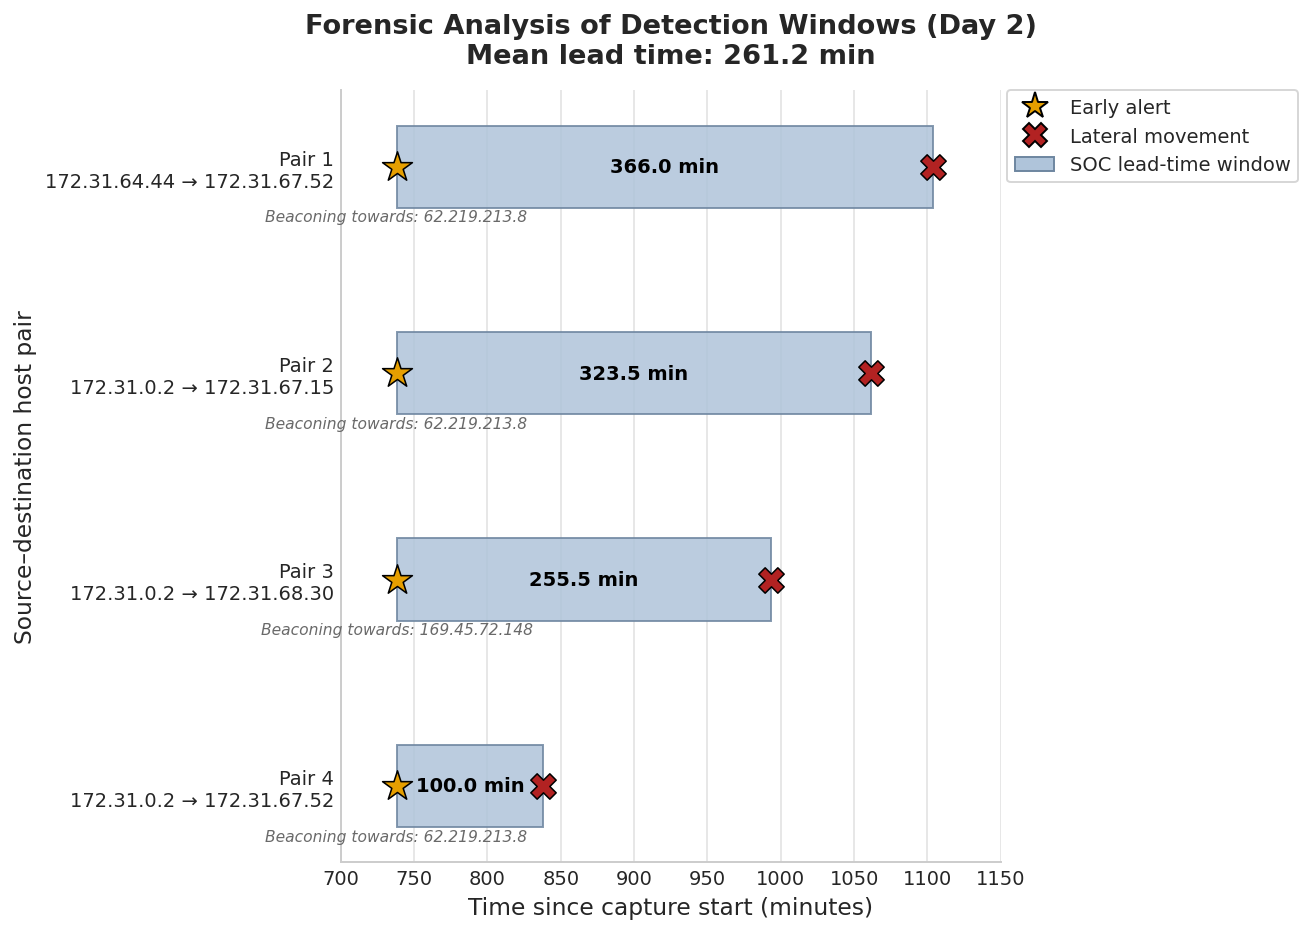

In [110]:
# =========================================================
# 1. DATA PREP
# =========================================================
df_plot = df_lm_pairs.copy()

# Choose the sorting criterion
# Option A: sort by lateral movement time (largest on top)
df_plot = df_plot.sort_values(by='Lateral_Movement_Min', ascending=False).reset_index(drop=True)

# If we want Pair 1 at the bottom, keep y positions normal and invert the y-axis later.
# Labels in English
y_labels = [
    f"Pair {i+1}\n{row['LM_Source']} → {row['LM_Dest']}"
    for i, row in df_plot.iterrows()
]

avg_lead_time = df_plot['Lead_Time_Min'].mean()

# =========================================================
# 2. FIGURE STYLE
# =========================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans"
})

fig, ax = plt.subplots(figsize=(11.5, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Softer, paper-friendly colors
bar_color = "#AFC4DA"        # muted blue
bar_edge = "#6E86A0"
alert_color = "#E69F00"      # colorblind-friendly orange
lm_color = "#B22222"         # dark red

y_positions = np.arange(len(df_plot))
bar_height = 0.40

# =========================================================
# 3. PLOT ELEMENTS
# =========================================================
# Lead-time window
bars = ax.barh(
    y_positions,
    df_plot["Lead_Time_Min"],
    left=df_plot["First_Alert_Min"],
    height=bar_height,
    color=bar_color,
    edgecolor=bar_edge,
    linewidth=1.0,
    alpha=0.85,
    zorder=2
)

# Early alert marker
ax.scatter(
    df_plot["First_Alert_Min"],
    y_positions,
    color=alert_color,
    edgecolor="black",
    linewidth=0.8,
    marker="*",
    s=260,
    zorder=4
)

# Lateral movement marker
ax.scatter(
    df_plot["Lateral_Movement_Min"],
    y_positions,
    color=lm_color,
    edgecolor="black",
    linewidth=0.8,
    marker="X",
    s=170,
    zorder=4
)

# =========================================================
# 4. ANNOTATIONS
# =========================================================
for i, row in df_plot.iterrows():
    start = row["First_Alert_Min"]
    end = row["Lateral_Movement_Min"]
    lead = row["Lead_Time_Min"]
    center = start + lead / 2

    detalle = row["Forensic_Detail"]

    # Lead time text inside the bar
    ax.text(
        center, y_positions[i],
        f"{lead:.1f} min",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black",
        zorder=5
    )

    # Milestone labels slightly above markers
    # ax.annotate(
    #     "Early alert",
    #     xy=(start, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=alert_color, fontweight="bold"
    # )

    ax.annotate(
        detalle,
        xy=(start, y_positions[i]),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center", va="top",
        fontsize=8, color="dimgray", style="italic",
        zorder=6
    )

    # ax.annotate(
    #     "Lateral movement",
    #     xy=(end, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=lm_color, fontweight="bold"
    # )




# =========================================================
# 5. AXES, TICKS, GRID
# =========================================================
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

ax.set_xlim(700, 1150)
ax.set_xlabel("Time since capture start (minutes)")
ax.set_ylabel("Source–destination host pair")

ax.set_title(
    f"Forensic Analysis of Detection Windows (Day 2)\n"
    f"Mean lead time: {avg_lead_time:.1f} min",
    pad=14,
    fontweight="bold"
)

# If we want Pair 1 at the bottom:
ax.invert_yaxis()

# Tick formatting: t = ...
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"t={int(x)}"))

# Subtle grid for paper
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8, alpha=0.8)
ax.grid(axis="y", visible=False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# 6. LEGEND OUTSIDE THE PLOT
# =========================================================
legend_handles = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor=alert_color, markeredgecolor="black",
           markersize=14, label="Early alert"),
    Line2D([0], [0], marker="X", color="w",
           markerfacecolor=lm_color, markeredgecolor="black",
           markersize=12, label="Lateral movement"),
    Patch(facecolor=bar_color, edgecolor=bar_edge,
          label="SOC lead-time window")
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    borderaxespad=0.0
)

# Leave space on the right for the legend
plt.tight_layout(rect=[0, 0, 0.83, 1])

# Best format for paper
# plt.savefig("forensic_detection_windows_day1.pdf", bbox_inches="tight")
# plt.savefig("forensic_detection_windows_day1.png", bbox_inches="tight", dpi=300)

plt.show()